In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import colors, pyplot as plt
from sklearn.discriminant_analysis import StandardScaler
from sklearn.manifold import TSNE
import torch
from utils.vis_related import get_label_sep_points, plot_one_label
from ChromaPalette.chroma_palette import *


def load_filter_tabular_data(imaging_id_list, tab_csv, selected_col_names):
    """ Sort the tabular data based on subject ids so that the order of data is the same as for the subject order
    in imaging paths """
    filtered_tab = tab_csv[tab_csv["eid"].isin(imaging_id_list)]
    ordered_tab = filtered_tab.set_index("eid").reindex(imaging_id_list).reset_index()
    if selected_col_names != None:
        if isinstance(selected_col_names, str):
            selected_col_names = [selected_col_names]
        col_names = ["eid"] + selected_col_names
        ordered_tab = ordered_tab[col_names]
        bool_columns = ordered_tab.columns[ordered_tab.dtypes == bool]
        ordered_tab[bool_columns] = ordered_tab[bool_columns].astype(int)
    else:
        ordered_tab = ordered_tab.drop("eid", axis=1)
    return ordered_tab

/u/home/zyun/miniconda3/envs/kmae_39/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

pheno_value_names = ["LVEDV (mL)", "LVESV (mL)", "LVSV (mL)", "LVEF (%)", "LVCO (L/min)", "LVM (g)", "RVEDV (mL)", "RVESV (mL)", "RVSV (mL)", "RVEF (%)"]

morph_value_names = [
    "Systolic Blood Pressure",
    "Diastolic Blood Pressure",
    "Pulse Rate",
    "Body Fat Percentage",
    "Whole Body Water Mass",
    "Body Mass Index (BMI)",
    "Waist Circumference",
    "Height",
    "Weight",
    "Cardiac Index",
    "Average Heart Rate",
    "Systolic Brachial Blood Pressure During PWA",
    "End Systolic Pressure During PWA",
    "Stroke Volume During PWA",
    "Mean Arterial Pressure During PWA",
    "Sleep Duration"
]

morph_raw_value_names = [
      "Systolic blood pressure-2.mean",
      "Diastolic blood pressure-2.mean",
      "Pulse rate-2.mean",
      "Body fat percentage-2.0",
      "Whole body water mass-2.0",
      "Body mass index (BMI)-2.0",
      "Waist circumference-2.0",
      "Height-2.0",
      "Weight-2.0",
      "Cardiac index-2.0",
      "Average heart rate-2.0",
      "Systolic brachial blood pressure during PWA-2.0",
      "End systolic pressure during PWA-2.0",
      "Stroke volume during PWA-2.0",
      "Mean arterial pressure during PWA-2.0",
      "Sleep duration-2.0"
      ]

with open("datasets/data_files/tabular_files/raw_tab_paul_new.csv", "rb") as file:
    tabular_raw_data = pd.read_csv(file)


# Generate class token t-SNE

In [3]:
def get_label_sep_points(label_name, phenotype_labels):
    probability = [0, 0.2, 0.4, 0.6, 0.8, 1]
    if label_name == "LVCO (L/min)":
        probability = [0, 0.1, 0.3, 0.7, 0.9, 1]

    label_sep_points = np.quantile(phenotype_labels, probability, method="closest_observation")
    label_sep_points = [int(p) for p in label_sep_points]
    return label_sep_points

In [4]:
latent_path = Path("embeddings_c1_588_42k.npz")
latent_raw_file = np.load(latent_path)
latent_path = Path("embeddings_c1_588_42k.npz")
latent_raw_file = np.load(latent_path)
cls_tokens = latent_raw_file["cls_tokens"]
subj_id = latent_raw_file["subj_ids"]
print(cls_tokens.shape, subj_id.shape)
pheno_tab_raw = load_filter_tabular_data(list(subj_id), tabular_raw_data, pheno_value_names)
morph_tab_raw = load_filter_tabular_data(list(subj_id), tabular_raw_data, morph_raw_value_names)

(42000, 1025) (42000,)


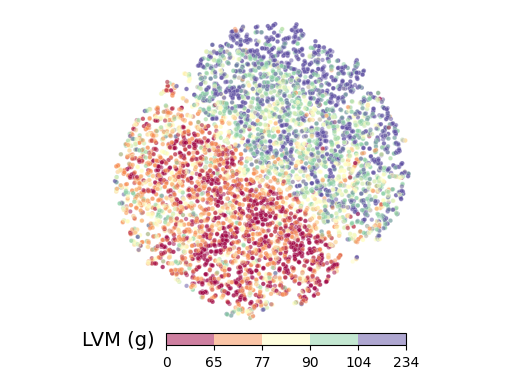

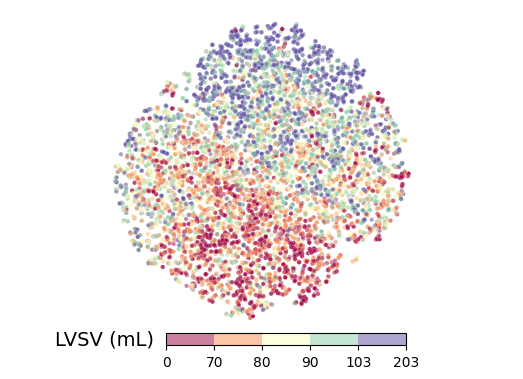

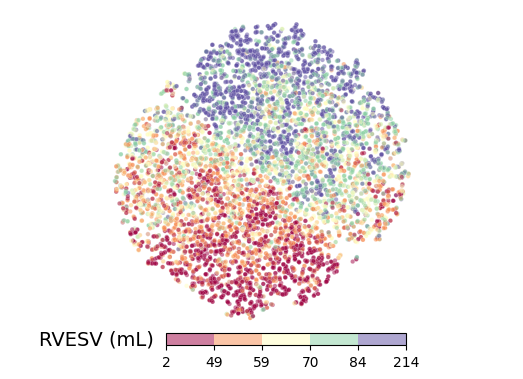

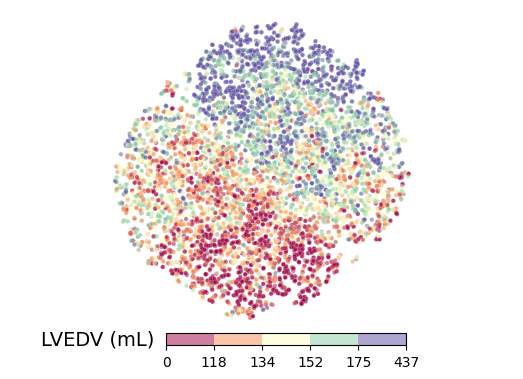

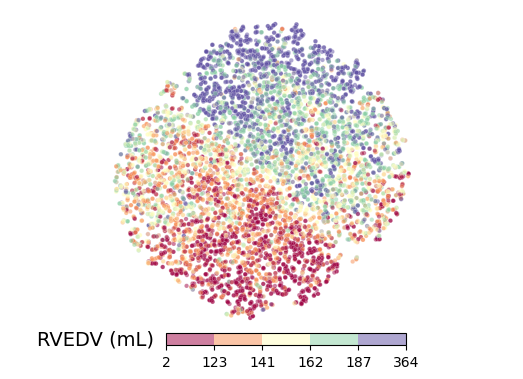

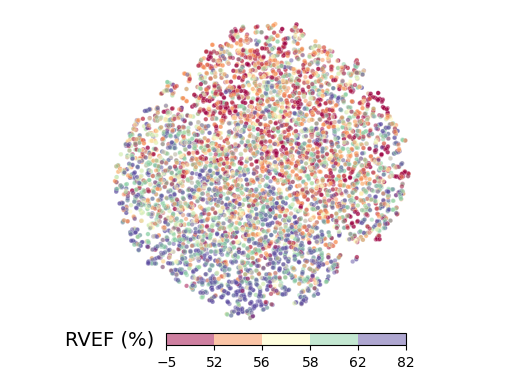

In [6]:
SCALE_MAP = True
num_cases = 10000

pheno_value_names = ["LVM (g)", "LVSV (mL)", "RVESV (mL)", "LVEDV (mL)", "RVEDV (mL)", "RVEF (%)"]
if SCALE_MAP:
    cls_tokens = StandardScaler().fit_transform(cls_tokens)
reducer = TSNE(2, perplexity=5, learning_rate="auto")
map_cls = reducer.fit_transform(cls_tokens[:num_cases])
for i in range(len(pheno_value_names)):
# i = 0
    name = pheno_value_names[i]
    labels = pheno_tab_raw[f"{name}"].copy()
    labels = labels[:num_cases]
    labels = np.array(labels) if isinstance(labels, torch.Tensor) else labels
    mask = ~np.isnan(labels)
    labels = labels[mask]
    sep_points = get_label_sep_points(name, labels)

    # if name in ["LVEF (%)", "RVEF (%)"]: continue
    cmap = plt.get_cmap('Spectral')
    norm = colors.BoundaryNorm(sep_points, cmap.N)
    # color_list = color_palette(name="Radiant", N=8)
    # cmap = colors.ListedColormap(color_list)  # Convert list to colormap
    # norm = colors.BoundaryNorm(sep_points, len(color_list))

    plt.figure(figsize=(6.5, 6))
    plt.scatter(map_cls[:, 0][mask], map_cls[:, 1][mask], c=labels.values.astype(float), cmap=cmap, norm=norm, 
                s=10, alpha=.5, 
                edgecolor='white', linewidths=.2,
                )
    cbar = plt.colorbar(boundaries=sep_points, ticks=sep_points, orientation="horizontal")
    cbar.ax.set_position([0.25, 0.32, 0.6, 0.02])
    cbar.ax.text(-0.05, 0.5, f'{name}', va='center', ha='right', fontsize=14, transform=cbar.ax.transAxes)

    # Remove frame (spines)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.xticks([])
    plt.yticks([])

    plt.gca().set_aspect('equal', 'datalim')
    # plt.title(f't-SNE projection of {name}', fontsize=24)
    
    # Save or show the plot
    name = name.replace("/", "_")
    name = name.replace("%", "_")
    # plt.savefig(f"results_scripts/tsne_plots/tsne_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from matplotlib import colors
import imageio.v2 as imageio
from io import BytesIO

SCALE_MAP = True
num_cases = 10000

pheno_value_names = ["LVM (g)", "LVSV (mL)", "RVESV (mL)", "LVEDV (mL)", "RVEDV (mL)", "RVEF (%)"]
full_name = ["Left Ventricular \nMass (LVM)", 
             "Left Ventricular \nStroke Volumne \n(LVSV)", 
             "Right Ventricular \nEnd-systolic \nVolumn (RVESV)", 
             "Left Ventricular \nEnd-diastolic \nVolumn (LVEDV)", 
             "Right Ventricular \nEnd-diastolic \nVolumn (RVEDV)", 
             "Right Ventricular \nEjection Fraction \n(RVEF)",
             ]
if SCALE_MAP:
    cls_tokens = StandardScaler().fit_transform(cls_tokens)
reducer = TSNE(2, perplexity=5, learning_rate="auto")
map_cls = reducer.fit_transform(cls_tokens[:num_cases])

frames = []

for i in range(len(pheno_value_names)):
    name = pheno_value_names[i]
    labels = pheno_tab_raw[f"{name}"].copy()
    labels = labels[:num_cases]
    labels = np.array(labels) if isinstance(labels, torch.Tensor) else labels
    mask = ~np.isnan(labels)
    labels = labels[mask]
    sep_points = get_label_sep_points(name, labels)

    cmap = plt.get_cmap('Spectral')
    norm = colors.BoundaryNorm(sep_points, cmap.N)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    sc = ax.scatter(map_cls[:, 0][mask], map_cls[:, 1][mask], c=labels.astype(float), cmap=cmap, norm=norm,
                    s=10, alpha=.5, edgecolor='white', linewidths=.2)
    cbar = plt.colorbar(sc, ax=ax, boundaries=sep_points, ticks=sep_points, orientation="horizontal")
    cbar.ax.set_position([0.25, 0.32, 0.6, 0.02])
    cbar.ax.text(-0.05, 0.5, f'{name}', va='center', ha='right', fontsize=14, transform=cbar.ax.transAxes)

    ax.text(0.01, 0.99, full_name[i], transform=ax.transAxes,
        fontsize=14, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_aspect('equal', 'datalim')

    # Save figure to buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches="tight", dpi=300)
    buf.seek(0)
    image = imageio.imread(buf)
    frames.append(image)
    plt.close(fig)

# Save the list of images as a GIF
imageio.mimsave("tsne_visualization.gif", frames, duration=1200)  # 1.5s per frame
with imageio.get_writer("test.gif", mode="I", duration=1200) as writer:
    for f in frames*2:  # Two rounds
        writer.append_data(f)

# Temporal t-SNE

In [6]:
latent_path = Path("embeddings_c1_588_10k_temp_test.npz")
latent_raw_file = np.load(latent_path)
temp_embeddings = latent_raw_file["temp_embeddings"]
subj_id = latent_raw_file["subj_ids"]
print(temp_embeddings.shape, subj_id.shape)

(1000, 10, 1025) (1000,)


In [8]:
num_t = 10
num_subj = 1000

tmp_emb = temp_embeddings[:num_subj].reshape(-1, temp_embeddings.shape[2])
scaled_tmp = StandardScaler().fit_transform(tmp_emb)
map_temp_2d = TSNE(n_components=2, perplexity=5, learning_rate="auto").fit_transform(scaled_tmp)
map_temp_3d = TSNE(n_components=3, perplexity=5, learning_rate="auto").fit_transform(scaled_tmp)

tmps = np.arange(num_t).reshape(1, -1)
tmp_labels = np.tile(tmps, (num_subj, 1))
labels = tmp_labels.reshape(-1)

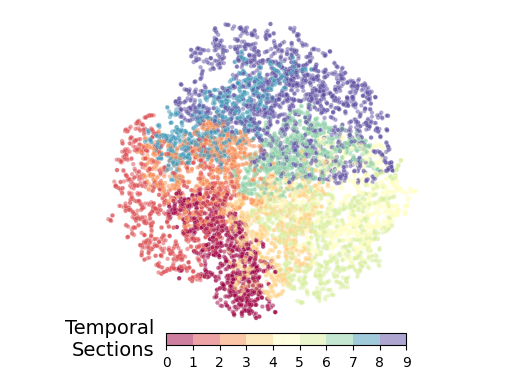

In [21]:
sep_points = [i for i in np.arange(10)]
cmap = plt.get_cmap('Spectral')
norm = colors.BoundaryNorm(sep_points, cmap.N)
color_list = color_palette(name="BlueGradient", N=10)
# cmap = colors.ListedColormap(color_list)  # Convert list to colormap
# norm = colors.BoundaryNorm(sep_points, len(color_list))

plt.figure(figsize=(6.5, 6))
for i in range(10):
    # Extract the points for case i
    points = map_temp_2d[i: i*10]
    
    # # Plot the points with a line connecting them
    # case_color = color_list[i]
    # plt.plot(points[:, 0], points[:, 1], c=case_color, lw=1)  # Connect points with a line

plt.scatter(map_temp_3d[:, 1], map_temp_3d[:, 2], c=labels, cmap=cmap, norm=norm, 
            s=10, alpha=.5, 
            edgecolor='white', linewidths=.2,
            )
cbar = plt.colorbar(boundaries=[i-0.5 for i in np.arange(10+1)], ticks=sep_points, orientation="horizontal")
cbar.ax.set_position([0.25, 0.32, 0.6, 0.02])
cbar.ax.text(-0.05, 0.5, f'Temporal\nSections', va='center', ha='right', fontsize=14, transform=cbar.ax.transAxes)

# Remove frame (spines)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.xticks([])
plt.yticks([])

plt.gca().set_aspect('equal', 'datalim')

# Save or show the plot
# plt.savefig(f"results_scripts/tsne_plots/tsne_temp.png", dpi=300, bbox_inches="tight")
plt.show()

(1000, 10, 1025) (1000,)


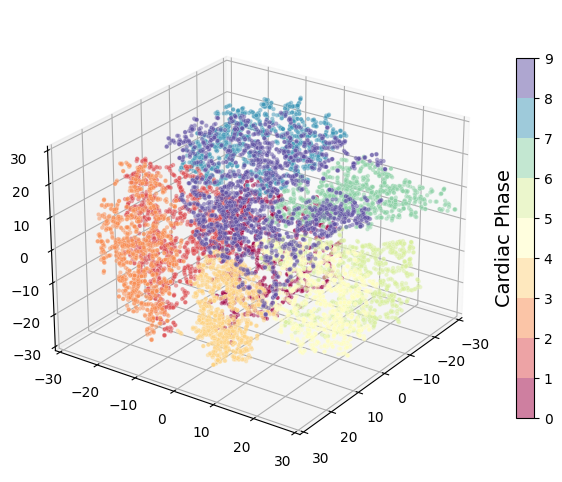

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from seaborn import color_palette
from mpl_toolkits.mplot3d import Axes3D
latent_path = Path("embeddings_c1_588_10k_temp_test.npz")
latent_raw_file = np.load(latent_path)
temp_embeddings = latent_raw_file["temp_embeddings"]
subj_id = latent_raw_file["subj_ids"]
print(temp_embeddings.shape, subj_id.shape)

num_t = 10
num_subj = 1000

tmp_emb = temp_embeddings[:num_subj].reshape(-1, temp_embeddings.shape[2])
scaled_tmp = StandardScaler().fit_transform(tmp_emb)
map_temp_2d = TSNE(n_components=2, perplexity=5, learning_rate="auto").fit_transform(scaled_tmp)
map_temp_3d = TSNE(n_components=3, perplexity=5, learning_rate="auto").fit_transform(scaled_tmp)

tmps = np.arange(num_t).reshape(1, -1)
tmp_labels = np.tile(tmps, (num_subj, 1))
labels = tmp_labels.reshape(-1)
# Define color mapping
sep_points = [i for i in np.arange(10)]
cmap = plt.get_cmap('Spectral')
norm = colors.BoundaryNorm(sep_points, cmap.N)
# color_list = color_palette(name="BlueGradient", N=10)

# Create a 3D figure
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(map_temp_3d[:, 0], map_temp_3d[:, 1], map_temp_3d[:, 2], 
                c=labels, cmap=cmap, norm=norm, 
                s=10, alpha=.5, edgecolor='white', linewidths=.2)

# Add colorbar
cbar = fig.colorbar(sc, boundaries=[i-0.5 for i in np.arange(10+1)], ticks=sep_points, orientation="vertical")
cbar.ax.set_position([0.77, 0.2, 0.05, 0.6])  # Position it on the right side
cbar.ax.text(-0.1, 0.5, f'Cardiac Phase', va='center', ha='right', fontsize=14, transform=cbar.ax.transAxes, rotation=90)
ax.set_xlim([-30, 30])  # Set x-axis limits for zooming
ax.set_ylim([-30, 30])  # Set y-axis limits for zooming
ax.set_zlim([-30, 30])  # Set z-axis limits for zooming

# Adjust viewing angle
ax.view_init(elev=25, azim=35)
plt.savefig(f"results_scripts/tsne_plots/tsne_temp_3d.png", dpi=300, bbox_inches="tight")
# Show plot
plt.show()


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from seaborn import color_palette
from mpl_toolkits.mplot3d import Axes3D

num_t = 10
num_subj = 1000

tmp_emb = temp_embeddings[:num_subj].reshape(-1, temp_embeddings.shape[2])
scaled_tmp = StandardScaler().fit_transform(tmp_emb)
map_temp_2d = TSNE(n_components=2, perplexity=5, learning_rate="auto").fit_transform(scaled_tmp)
map_temp_3d = TSNE(n_components=3, perplexity=5, learning_rate="auto").fit_transform(scaled_tmp)

tmps = np.arange(num_t).reshape(1, -1)
tmp_labels = np.tile(tmps, (num_subj, 1))
labels = tmp_labels.reshape(-1)
# Define color mapping
sep_points = [i for i in np.arange(10)]
cmap = plt.get_cmap('Spectral')
norm = colors.BoundaryNorm(sep_points, cmap.N)

frames = []


for i in range(num_t):
    fig = plt.figure(figsize=(12, 6), facecolor='white')
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('white')  # Set the axes background

    # Scatter plot
    map_temp = map_temp_3d.reshape(-1, num_t, 3)
    map_temp_ = map_temp[:, :i].reshape(-1, 3)
    sc = ax.scatter(map_temp_[:, 0], map_temp_[:, 1], map_temp_[:, 2], 
                    c=tmp_labels[:, :i].reshape(-1), cmap=cmap, norm=norm, 
                    s=10, alpha=.5, edgecolor='white', linewidths=.2)

    # Add colorbar
    cbar = fig.colorbar(sc, boundaries=[i-0.5 for i in np.arange(10+1)], ticks=sep_points, orientation="vertical")
    cbar.ax.set_position([0.77, 0.2, 0.05, 0.6])  # Position it on the right side
    cbar.ax.text(-0.1, 0.5, f'Cardiac Phase', va='center', ha='right', fontsize=14, transform=cbar.ax.transAxes, rotation=90)
    # Adjust viewing angle
    ax.view_init(elev=25, azim=35)
    ax.set_xlim([-30, 30])  # Set x-axis limits for zooming
    ax.set_ylim([-30, 30])  # Set y-axis limits for zooming
    ax.set_zlim([-30, 30])  # Set z-axis limits for zooming

    # Save figure to buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches="tight", dpi=300, facecolor='white')
    buf.seek(0)
    image = imageio.imread(buf)
    frames.append(image)
    plt.close(fig)

# Save the list of images as a GIF
imageio.mimsave("tsne_tempo.gif", frames, duration=1200)  # 1.5s per frame


In [ ]:
import plotly.express as px
scatter_data = {"x": map_temp_3d[:, 0], "y": map_temp_3d[:, 1], "z": map_temp_3d[:, 2], "time": labels}
df_scatter = pd.DataFrame(scatter_data)
fig = px.scatter_3d(
    df_scatter, 
    x='x', y='y', z='z', 
    color='time',
    # title=f"{map_type} maps for temporal sections",
    labels={'label': 'Time'},
    hover_data={'time': True, 'x': False, 'y': False, 'z': False},
)
fig.update_traces(mode='markers+text')
fig.update_traces(marker=dict(size=1))
fig.show()